In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# user_id: A unique identifier for the customer.

# product_id: A unique identifier for the specific product.

# category: The high-level product group (e.g., Electronics).

# subcategory: The specific department within a category (e.g., Mobile).

# brand: The company that manufactured the product.

# price: The original listed cost before any deductions.

# discount: The percentage taken off the original price.

# final_price: The actual amount paid after the discount is applied.

# rating: The average customer score out of 5 stars.

# review_count: The total number of written reviews for the item.

# stock: The current number of units available for sale.

# seller_id: A unique identifier for the merchant selling the item.

# seller_rating: The performance score assigned to the seller.

# purchase_date: The date the transaction was completed.

# shipping_time_days: The number of days it took to deliver the order.

# location: The city where the customer is located.

# device: The hardware used to place the order (e.g., Tablet).

# payment_method: The system used for payment (e.g., UPI).

# is_returned: A true/false flag indicating if the item was sent back.

# delivery_status: The current tracking state of the package.

In [3]:
df=pd.read_csv(r"C:\Users\nares\Downloads\amazon_ecommerce_mar2025_mar2026.csv")

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54183 entries, 0 to 54182
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             54183 non-null  object 
 1   product_id          54183 non-null  object 
 2   category            54183 non-null  object 
 3   subcategory         54183 non-null  object 
 4   brand               54183 non-null  object 
 5   price               54183 non-null  float64
 6   discount            54183 non-null  float64
 7   final_price         54183 non-null  float64
 8   rating              54183 non-null  float64
 9   review_count        54183 non-null  int64  
 10  stock               54183 non-null  int64  
 11  seller_id           54183 non-null  object 
 12  seller_rating       54183 non-null  float64
 13  purchase_date       54183 non-null  object 
 14  shipping_time_days  54183 non-null  int64  
 15  location            54183 non-null  object 
 16  devi

In [21]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'], format='%d-%m-%Y')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54183 entries, 0 to 54182
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             54183 non-null  object        
 1   product_id          54183 non-null  object        
 2   category            54183 non-null  object        
 3   subcategory         54183 non-null  object        
 4   brand               54183 non-null  object        
 5   price               54183 non-null  float64       
 6   discount            54183 non-null  float64       
 7   final_price         54183 non-null  float64       
 8   rating              54183 non-null  float64       
 9   review_count        54183 non-null  int64         
 10  stock               54183 non-null  int64         
 11  seller_id           54183 non-null  object        
 12  seller_rating       54183 non-null  float64       
 13  purchase_date       54183 non-null  datetime64

In [4]:
df.head()

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U907645,P13100,Sports,Cycling,Nike,13307.41,24.89,9995.09,3.2,26,308,S4473,3.5,28-08-2025,4,Mumbai,Tablet,UPI,True,Returned
1,U995373,P11820,Electronics,Headphones,Samsung,5464.82,15.70,4606.69,3.1,5,453,S1390,2.7,05-10-2025,4,Mumbai,Tablet,Cash on Delivery,False,Delayed
2,U565186,P25469,Beauty,Makeup,Lenovo,3437.74,45.41,1876.51,3.7,41,222,S4525,3.5,29-10-2025,2,Hyderabad,Web,Debit Card,False,Delayed
3,U351028,P20410,Clothing,Men,Apple,967.17,30.44,672.76,3.9,18,471,S3841,3.3,06-04-2025,5,Delhi,Mobile App,Credit Card,False,Delayed
4,U462787,P23079,Beauty,Haircare,Sony,1963.36,35.43,1267.69,4.0,2,134,S7317,2.8,23-09-2025,6,Hyderabad,Tablet,Credit Card,True,Returned


In [5]:
#checking for null values.
# In this dataset there are no Non-Values
df.isna().sum()

user_id               0
product_id            0
category              0
subcategory           0
brand                 0
price                 0
discount              0
final_price           0
rating                0
review_count          0
stock                 0
seller_id             0
seller_rating         0
purchase_date         0
shipping_time_days    0
location              0
device                0
payment_method        0
is_returned           0
delivery_status       0
dtype: int64

In [6]:
df=df.set_index("purchase_date")

In [7]:
# I removed the user_id, product_id, and seller_id columns because they contain unique identifiers
df=df.drop(columns=["user_id","product_id","seller_id"])

In [8]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,device,payment_method,is_returned,delivery_status
purchase_date,,,,,,,,,,,,,,,,
28-08-2025,Sports,Cycling,Nike,13307.41,24.89,9995.09,3.2,26,308,3.5,4,Mumbai,Tablet,UPI,True,Returned
05-10-2025,Electronics,Headphones,Samsung,5464.82,15.70,4606.69,3.1,5,453,2.7,4,Mumbai,Tablet,Cash on Delivery,False,Delayed
29-10-2025,Beauty,Makeup,Lenovo,3437.74,45.41,1876.51,3.7,41,222,3.5,2,Hyderabad,Web,Debit Card,False,Delayed
06-04-2025,Clothing,Men,Apple,967.17,30.44,672.76,3.9,18,471,3.3,5,Delhi,Mobile App,Credit Card,False,Delayed
23-09-2025,Beauty,Haircare,Sony,1963.36,35.43,1267.69,4.0,2,134,2.8,6,Hyderabad,Tablet,Credit Card,True,Returned


In [9]:
# i am sorting the dataset by purchase_date column.
df=df.sort_values(by="purchase_date")

In [10]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,device,payment_method,is_returned,delivery_status
purchase_date,,,,,,,,,,,,,,,,
01-01-2026,Sports,Fitness,Boat,958.24,20.96,757.43,3.0,14,111,4.9,2,Mumbai,Web,UPI,False,In Transit
01-01-2026,Electronics,Mobile,H&M,65372.42,25.58,48649.87,4.9,31,287,2.6,1,Bangalore,Tablet,Cash on Delivery,False,Delayed
01-01-2026,Clothing,Kids,Boat,856.22,64.91,300.41,3.4,20,144,2.7,3,Bangalore,Tablet,Cash on Delivery,False,In Transit
01-01-2026,Home,Furniture,Lenovo,15919.98,9.54,14400.64,4.1,58,241,3.1,4,Mumbai,Web,Cash on Delivery,False,In Transit
01-01-2026,Electronics,Headphones,Lenovo,19568.08,33.98,12918.39,2.9,45,32,4.4,1,Delhi,Tablet,Debit Card,True,Returned


In [11]:
df["category"].value_counts(normalize=True)

Beauty         0.203237
Home           0.200026
Sports         0.199472
Electronics    0.199048
Clothing       0.198217
Name: category, dtype: float64

In [12]:
df["brand"].value_counts(normalize=True)

Nike       0.084916
Samsung    0.084436
Boat       0.084362
LG         0.084178
Sony       0.083956
HP         0.083827
Zara       0.083753
Adidas     0.082867
Lenovo     0.082775
H&M        0.082092
Puma       0.081834
Apple      0.081003
Name: brand, dtype: float64

In [13]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,device,payment_method,is_returned,delivery_status
purchase_date,,,,,,,,,,,,,,,,
01-01-2026,Sports,Fitness,Boat,958.24,20.96,757.43,3.0,14,111,4.9,2,Mumbai,Web,UPI,False,In Transit
01-01-2026,Electronics,Mobile,H&M,65372.42,25.58,48649.87,4.9,31,287,2.6,1,Bangalore,Tablet,Cash on Delivery,False,Delayed
01-01-2026,Clothing,Kids,Boat,856.22,64.91,300.41,3.4,20,144,2.7,3,Bangalore,Tablet,Cash on Delivery,False,In Transit
01-01-2026,Home,Furniture,Lenovo,15919.98,9.54,14400.64,4.1,58,241,3.1,4,Mumbai,Web,Cash on Delivery,False,In Transit
01-01-2026,Electronics,Headphones,Lenovo,19568.08,33.98,12918.39,2.9,45,32,4.4,1,Delhi,Tablet,Debit Card,True,Returned


TypeError: boxplot() got multiple values for keyword argument 'vert'

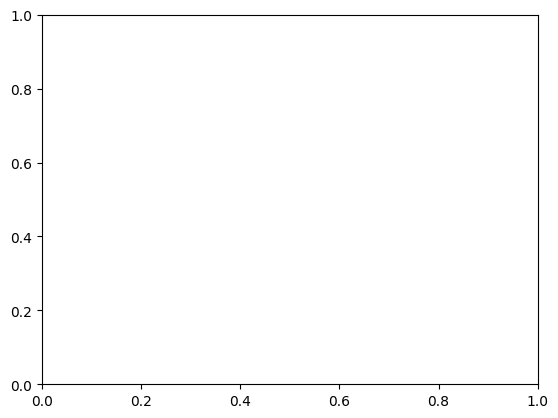

In [14]:
sns.boxplot(x=df["price"],vert=False)

In [ ]:
q3 = df["price"].quantile(0.75)
q1 = df["price"].quantile(0.25)

In [ ]:
iqr = q3 - q1
low = q1 - (1.5*iqr)  
high = q3 + (1.5*iqr)

In [ ]:
print(low)
print(high)

-14410.544999999995
31131.774999999994


In [ ]:
data_without_outliers = df["price"][(df["price"] >= low) & (df["price"] <= high)]

In [ ]:
data_without_outliers

purchase_date
01-01-2026      958.24
01-01-2026      856.22
01-01-2026    15919.98
01-01-2026    19568.08
01-01-2026     3533.95
                ...   
31-12-2025    10046.80
31-12-2025     2601.51
31-12-2025     1766.00
31-12-2025     8313.57
31-12-2025      852.63
Name: price, Length: 47185, dtype: float64

In [ ]:
df['price'].describe()

count    54183.000000
mean     13148.314033
std      18054.423251
min        200.260000
25%       2667.825000
50%       4931.540000
75%      14053.405000
max      79991.170000
Name: price, dtype: float64

In [ ]:
def replace_mean(point):
    if point <= low:
        point = df['price'].mean()
        return point
    elif point >= high:
        point = df['price'].mean()
        return point
    else:
        return point

In [ ]:
def replace_median(point):
    if point <= low:
        point = df['price'].median()
        return point
    elif point >= high:
        point = df['price'].median()
        return point
    else:
        return point

In [ ]:
def replace_custom(point):
    if point <= low:
        return 0
    elif point >= high:
        point = df['price'].mean()
        return 0
    else:
        return point

In [ ]:
outliers_mean = df["price"].apply(lambda point:replace_mean(point))
outliers_median = df["price"].apply(lambda point:replace_median(point))
outliers_custom = df["price"].apply(lambda point:replace_custom(point))

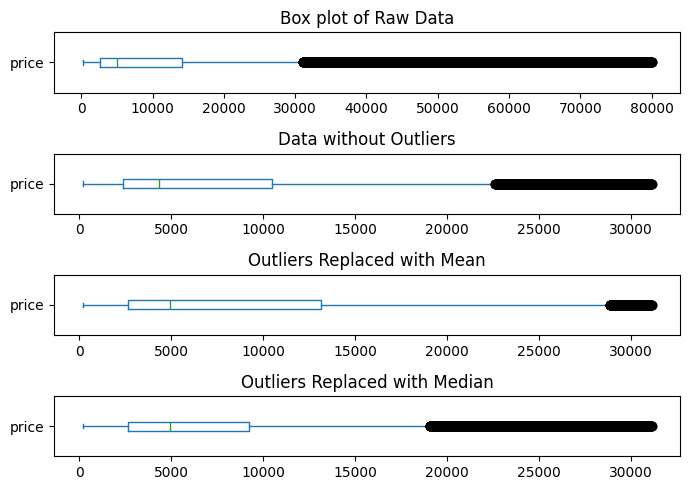

In [ ]:
figure,axes = plt.subplots(4,1,figsize=(7,5))
df["price"].plot(kind="box",vert=False,ax=axes[0])
axes[0].set_title("Box plot of Raw Data")

data_without_outliers.plot(kind="box",vert=False,ax=axes[1])
axes[1].set_title("Data without Outliers")

outliers_mean.plot(kind="box",vert=False,ax=axes[2])
axes[2].set_title("Outliers Replaced with Mean")

outliers_median.plot(kind="box",vert=False,ax=axes[3])
axes[3].set_title("Outliers Replaced with Median")

plt.tight_layout()
plt.show()

In [ ]:
outliers_median.describe()

count    54183.000000
mean      6606.339387
std       5780.918640
min        200.260000
25%       2667.825000
50%       4931.540000
75%       9233.540000
max      31131.350000
Name: price, dtype: float64

In [ ]:
print(df["price"].mean())
print(data_without_outliers.mean())
print(outliers_mean.mean())
print(outliers_median.mean())
print(outliers_custom.mean())

13148.31403281472
6854.728623291301
7667.576023690779
6606.339387077127
5969.406826679954


In [ ]:
print(df["price"].median())
print(data_without_outliers.median())
print(outliers_mean.median())
print(outliers_median.median())
print(outliers_custom.median())

4931.54
4346.83
4931.54
4931.54
3774.28


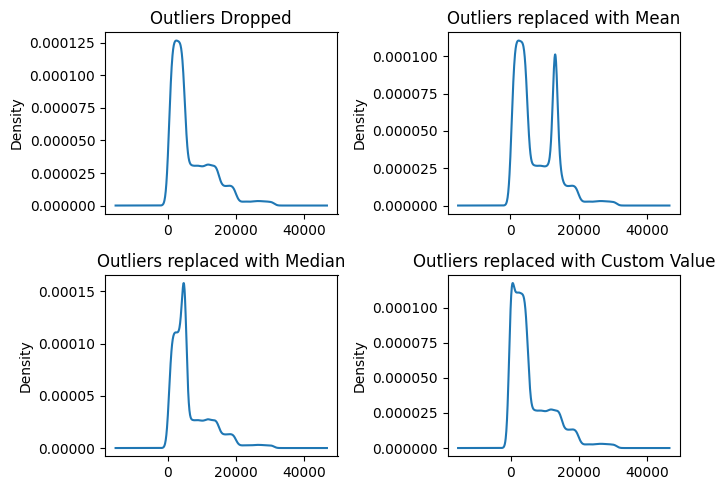

In [ ]:
figure,axes = plt.subplots(2,2,figsize=(7,5))
data_without_outliers.plot(kind="density",ax=axes[0,0])
axes[0,0].set_title("Outliers Dropped")

outliers_mean.plot(kind="density",ax=axes[0,1])
ax=axes[0,1].set_title("Outliers replaced with Mean")

outliers_median.plot(kind="density",ax=axes[1,0])
ax=axes[1,0].set_title("Outliers replaced with Median")

outliers_custom.plot(kind="density",ax=axes[1,1])
ax=axes[1,1].set_title("Outliers replaced with Custom Value")

plt.tight_layout()
plt.show()

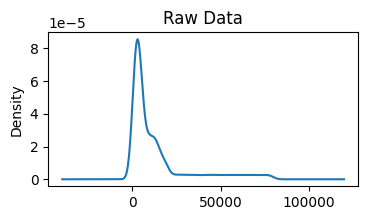

In [ ]:
plt.figure(figsize=(4,2))
df["price"].plot(kind="density")
plt.title("Raw Data")
plt.show()

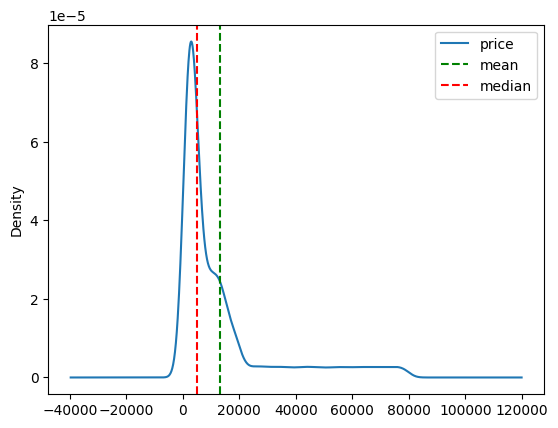

In [ ]:
df["price"].plot(kind="density")
plt.axvline(df["price"].mean(),linestyle="--",color="green",label="mean")
plt.axvline(df["price"].median(),linestyle="--",color="red",label="median")
plt.legend()
plt.show()

In [ ]:
#here I can sya that the data is positively skewed

In [ ]:
"https://learn.g2.com/hubfs/G2CM_FI703_Learn_Article_Images-%5BDescriptive_Statistics_2%5D_Infographic_V1a.png"

'https://learn.g2.com/hubfs/G2CM_FI703_Learn_Article_Images-%5BDescriptive_Statistics_2%5D_Infographic_V1a.png'

In [ ]:
df['price'].skew()

np.float64(2.141581631734233)

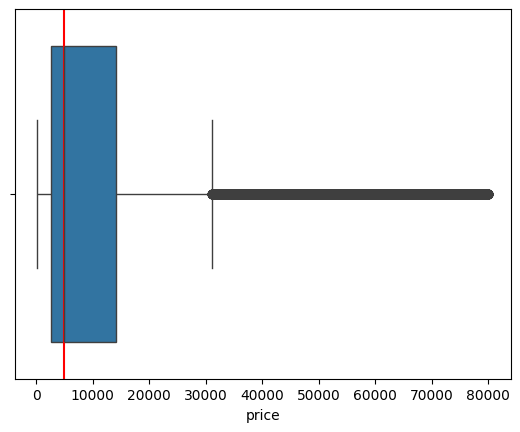

In [ ]:
sns.boxplot(x=df["price"],vert=False)
plt.axvline(df["price"].median(),color="red",label="median")

In [ ]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,device,payment_method,is_returned,delivery_status
purchase_date,,,,,,,,,,,,,,,,
01-01-2026,Sports,Fitness,Boat,958.24,20.96,757.43,3.0,14,111,4.9,2,Mumbai,Web,UPI,False,In Transit
01-01-2026,Electronics,Mobile,H&M,65372.42,25.58,48649.87,4.9,31,287,2.6,1,Bangalore,Tablet,Cash on Delivery,False,Delayed
01-01-2026,Clothing,Kids,Boat,856.22,64.91,300.41,3.4,20,144,2.7,3,Bangalore,Tablet,Cash on Delivery,False,In Transit
01-01-2026,Home,Furniture,Lenovo,15919.98,9.54,14400.64,4.1,58,241,3.1,4,Mumbai,Web,Cash on Delivery,False,In Transit
01-01-2026,Electronics,Headphones,Lenovo,19568.08,33.98,12918.39,2.9,45,32,4.4,1,Delhi,Tablet,Debit Card,True,Returned


<Axes: xlabel='brand'>

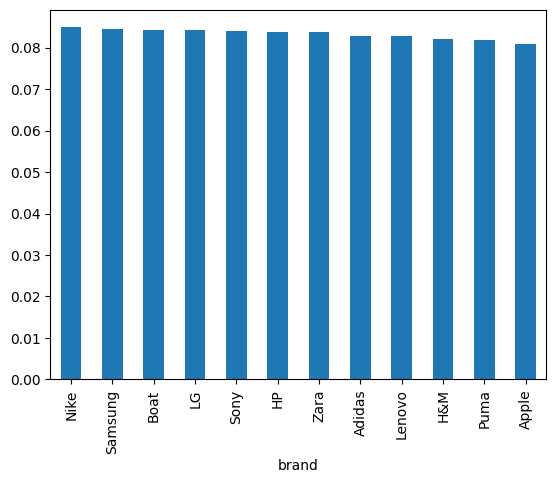

In [ ]:
df["brand"].value_counts(normalize=True).plot(kind="bar")

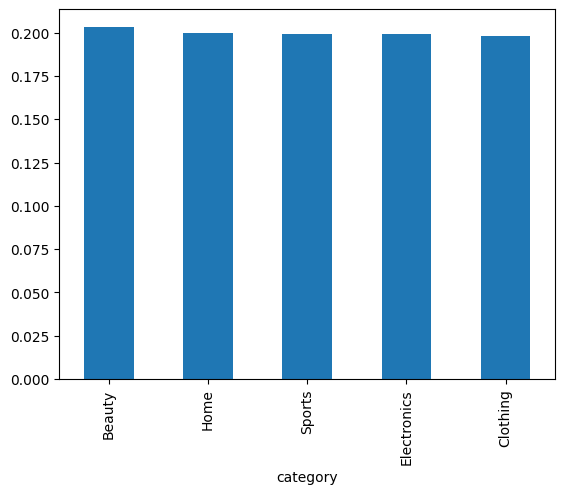

In [ ]:
df["category"].value_counts(normalize=True).plot(kind="bar")
plt.show()

<Axes: xlabel='location'>

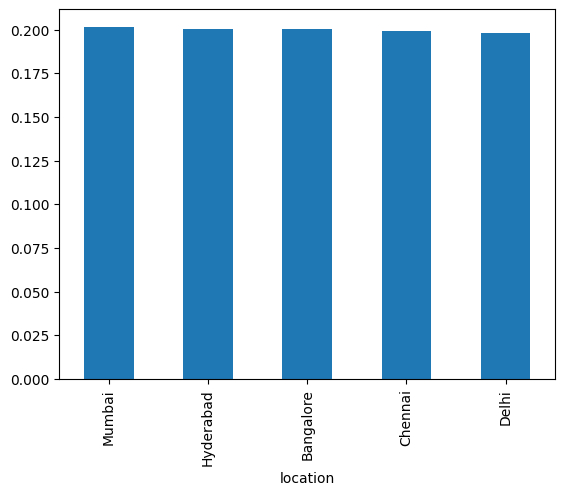

In [ ]:
df["location"].value_counts(normalize=True).plot(kind="bar")

<Axes: ylabel='proportion'>

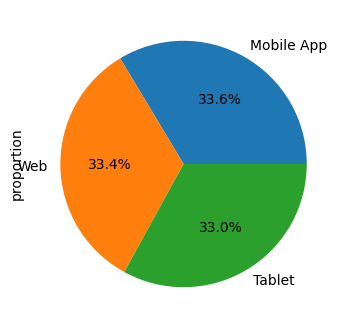

In [ ]:
plt.figure(figsize=(6,4))
df["device"].value_counts(normalize=True).plot(kind="pie", autopct="%1.1f%%")

In [ ]:
plt.show()

<Axes: >

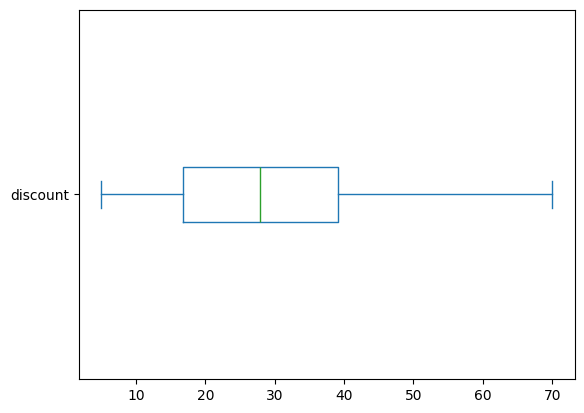

In [ ]:
df["discount"].plot(kind="box",vert=False)

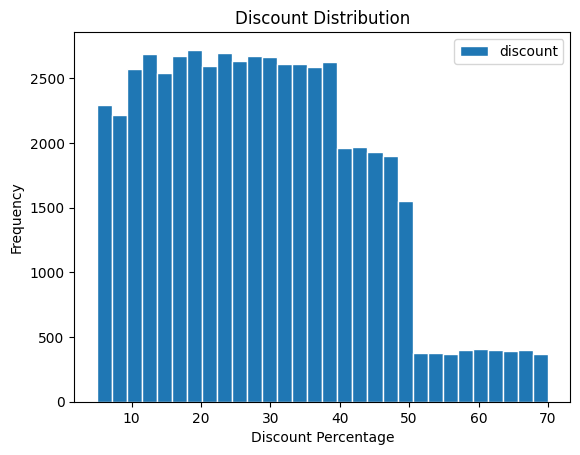

In [ ]:
df["discount"].plot(kind="hist", bins=30, edgecolor="white")
plt.xlabel("Discount Percentage")
plt.title("Discount Distribution")
plt.legend()
plt.show()

<Axes: xlabel='price', ylabel='Density'>

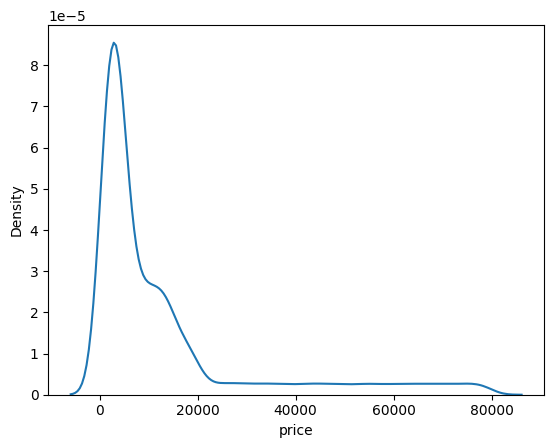

In [ ]:
sns.kdeplot(df["price"])

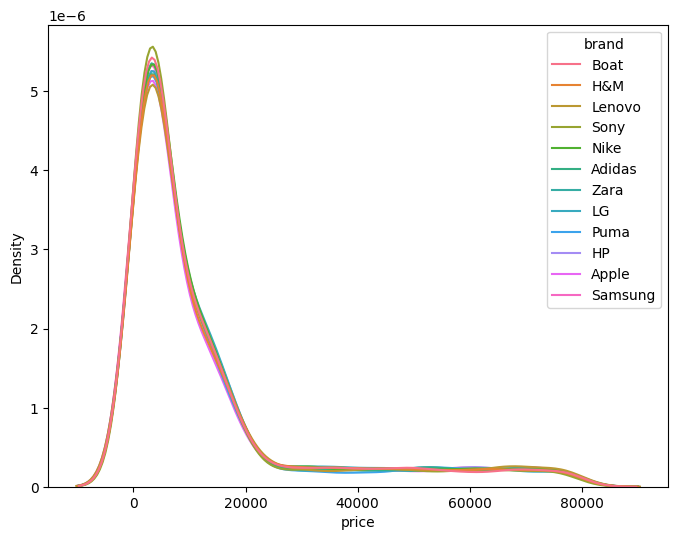

In [ ]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df,x="price",hue="brand")
plt.show()

In [ ]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,device,payment_method,is_returned,delivery_status
purchase_date,,,,,,,,,,,,,,,,
01-01-2026,Sports,Fitness,Boat,958.24,20.96,757.43,3.0,14,111,4.9,2,Mumbai,Web,UPI,False,In Transit
01-01-2026,Electronics,Mobile,H&M,65372.42,25.58,48649.87,4.9,31,287,2.6,1,Bangalore,Tablet,Cash on Delivery,False,Delayed
01-01-2026,Clothing,Kids,Boat,856.22,64.91,300.41,3.4,20,144,2.7,3,Bangalore,Tablet,Cash on Delivery,False,In Transit
01-01-2026,Home,Furniture,Lenovo,15919.98,9.54,14400.64,4.1,58,241,3.1,4,Mumbai,Web,Cash on Delivery,False,In Transit
01-01-2026,Electronics,Headphones,Lenovo,19568.08,33.98,12918.39,2.9,45,32,4.4,1,Delhi,Tablet,Debit Card,True,Returned


Text(0, 0.5, 'Frequency')

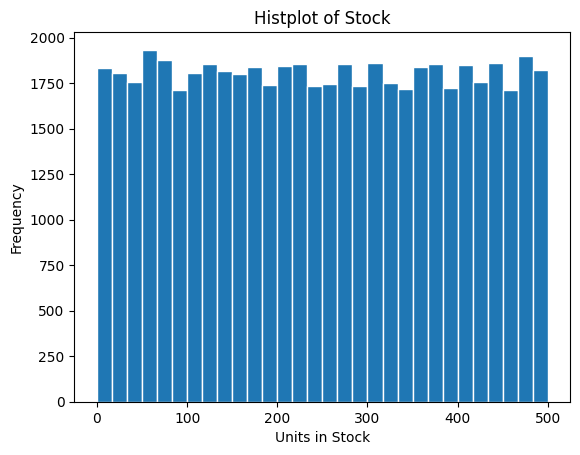

In [ ]:
df["stock"].plot(kind="hist", bins=30, edgecolor="white")
plt.title("Histplot of Stock")
plt.xlabel("Units in Stock")
plt.ylabel("Frequency")

In [ ]:
# And there are  no outliers present in this stock variable

Text(0.5, 1.0, 'Box Plot of Stock Levels')

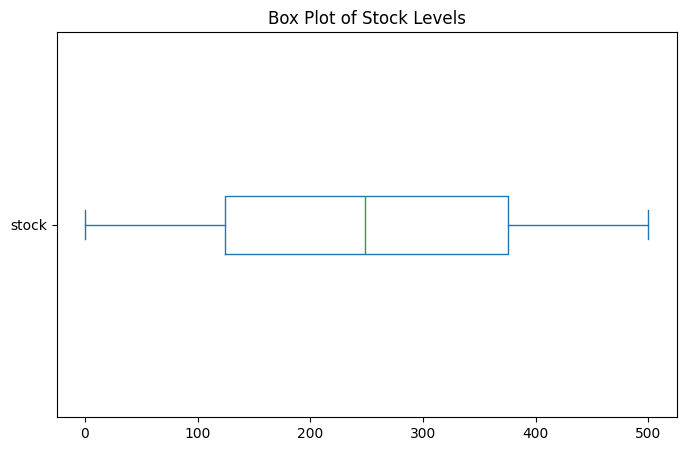

In [ ]:
plt.figure(figsize=(8,5))
df["stock"].plot(kind="box", vert=False)
plt.title("Box Plot of Stock Levels")

Text(0, 0.5, 'Count')

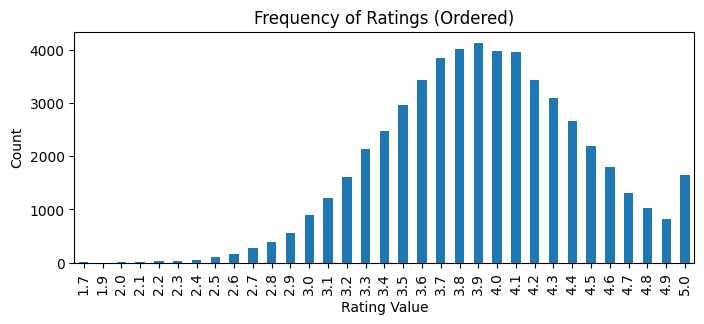

In [ ]:
plt.figure(figsize=(8,3))
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Frequency of Ratings (Ordered)")
plt.xlabel("Rating Value")
plt.ylabel("Count")

In [ ]:
df["rating"].skew()

np.float64(-0.06934736852750613)

<Axes: xlabel='payment_method'>

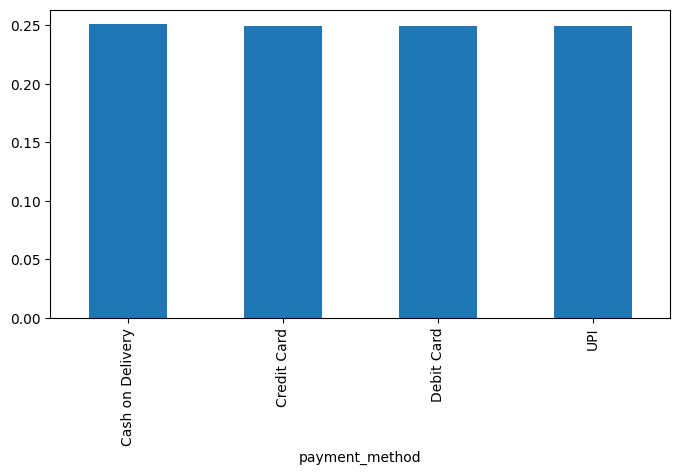

In [ ]:
plt.figure(figsize=(8,4))
df["payment_method"].value_counts(normalize=True).plot(kind="bar")

In [ ]:
plt.show()

In [ ]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,device,payment_method,is_returned,delivery_status
purchase_date,,,,,,,,,,,,,,,,
01-01-2026,Sports,Fitness,Boat,958.24,20.96,757.43,3.0,14,111,4.9,2,Mumbai,Web,UPI,False,In Transit
01-01-2026,Electronics,Mobile,H&M,65372.42,25.58,48649.87,4.9,31,287,2.6,1,Bangalore,Tablet,Cash on Delivery,False,Delayed
01-01-2026,Clothing,Kids,Boat,856.22,64.91,300.41,3.4,20,144,2.7,3,Bangalore,Tablet,Cash on Delivery,False,In Transit
01-01-2026,Home,Furniture,Lenovo,15919.98,9.54,14400.64,4.1,58,241,3.1,4,Mumbai,Web,Cash on Delivery,False,In Transit
01-01-2026,Electronics,Headphones,Lenovo,19568.08,33.98,12918.39,2.9,45,32,4.4,1,Delhi,Tablet,Debit Card,True,Returned


In [ ]:
cat_rate=df.groupby('category')['rating'].mean()
price_brand=df.groupby('brand')['price'].mean()

In [ ]:
price_brand

brand
Adidas     13176.182031
Apple      13202.763784
Boat       12961.750532
H&M        13247.714114
HP         13243.719954
LG         13299.550537
Lenovo     13550.553282
Nike       13251.322549
Puma       13062.095697
Samsung    13152.061895
Sony       12633.658885
Zara       13005.463927
Name: price, dtype: float64

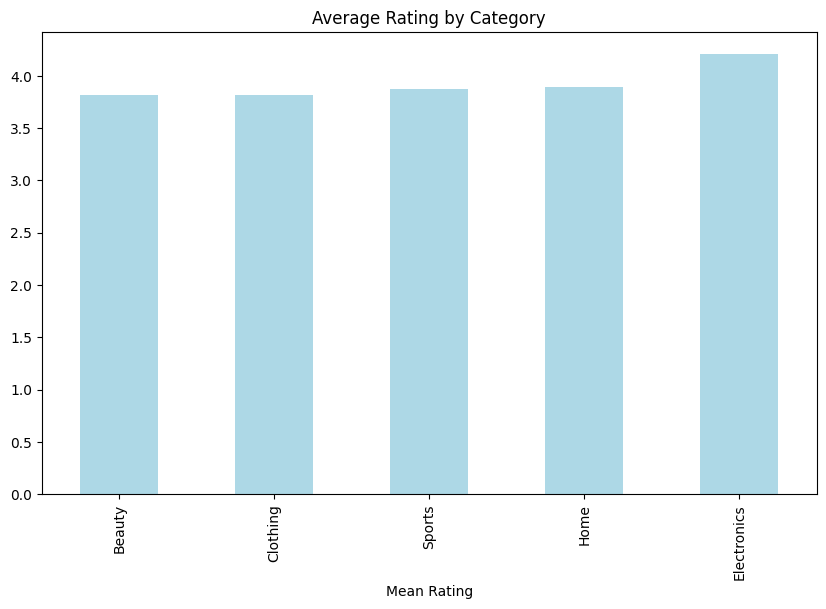

In [ ]:
# This groups the data so we see the "mean" rating for each category
plt.figure(figsize=(10, 6))
cat_rate.sort_values().plot(kind='bar', color='lightblue')
plt.title("Average Rating by Category")
plt.xlabel("Mean Rating")
plt.show()

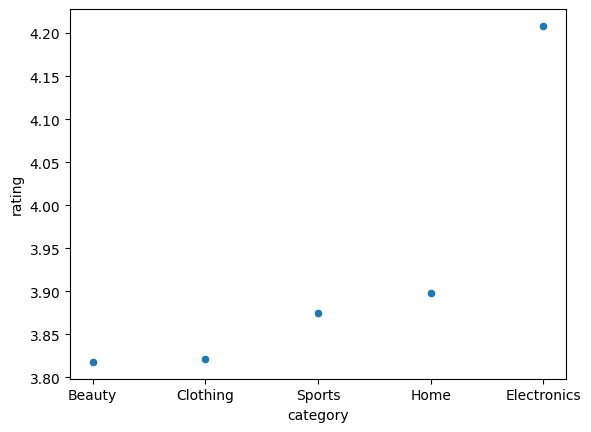

In [ ]:
sns.scatterplot(cat_rate.sort_values())
plt.show()

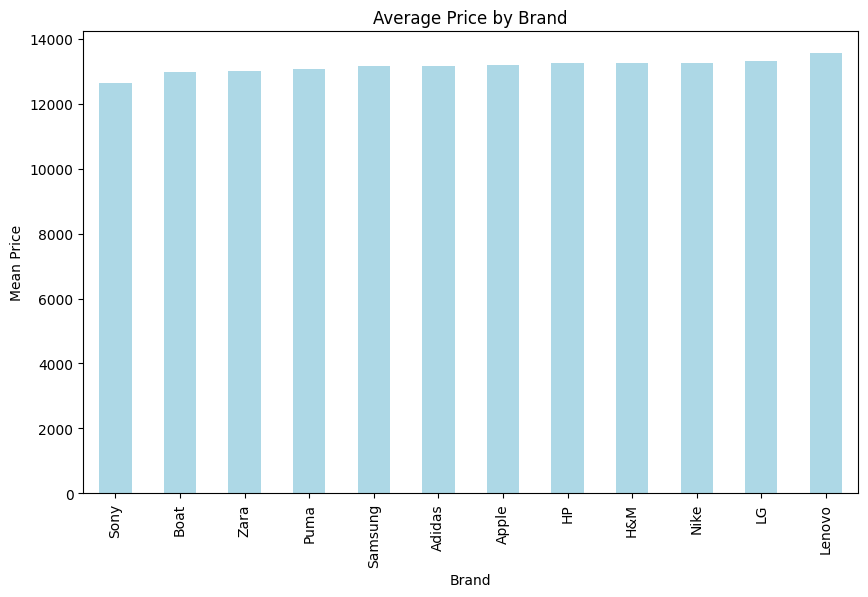

In [ ]:
plt.figure(figsize=(10, 6))
price_brand.sort_values().plot(kind='bar', color='lightblue')
plt.title("Average Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Mean Price")
plt.show()

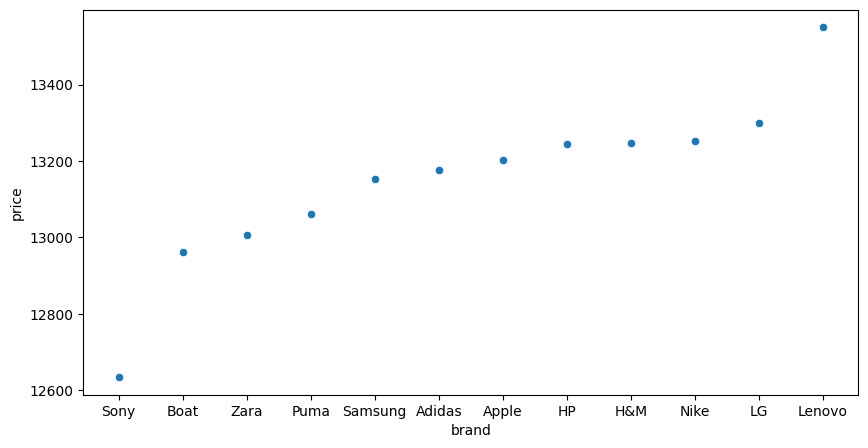

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(price_brand.sort_values())
plt.show()

In [ ]:
cat_price = df.groupby('category')['price'].median().sort_values().index

In [ ]:
cat_price

Index(['Beauty', 'Clothing', 'Sports', 'Home', 'Electronics'], dtype='object', name='category')

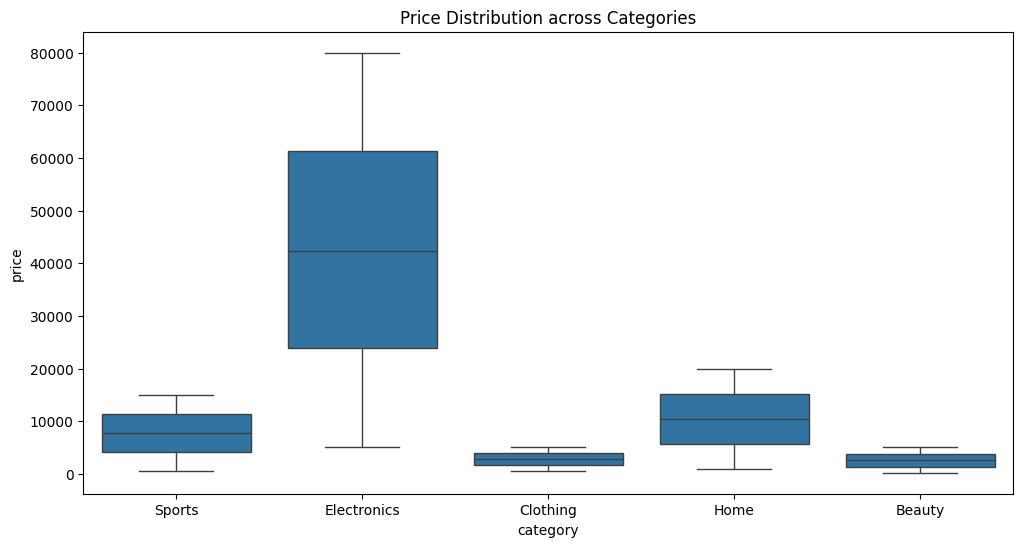

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='category', y='price')

plt.title("Price Distribution across Categories")
plt.show()

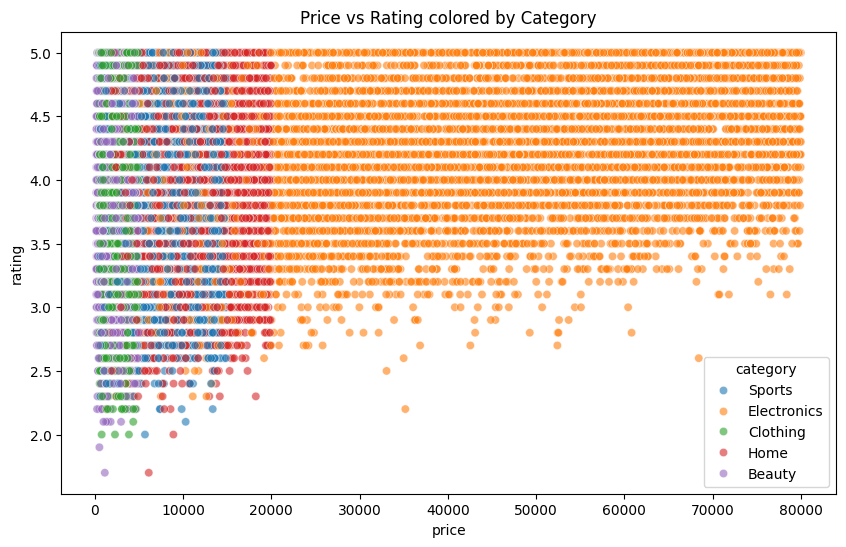

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='rating', hue='category', alpha=0.6)
plt.title("Price vs Rating colored by Category")
plt.show()

<Axes: >

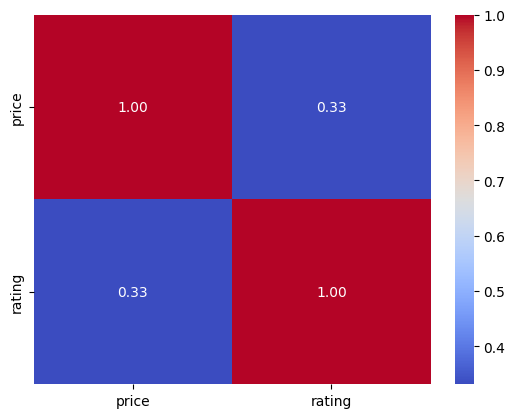

In [ ]:
sns.heatmap(df[["price","rating"]].corr(),annot=True, fmt=".2f", cmap="coolwarm")

In [ ]:
# # Create a pivot table of counts
# pivot_data = df.pivot_table(index='location', columns='category', values='price', aggfunc='count')

In [ ]:
# plt.figure(figsize=(12, 8))
# sns.heatmap(pivot_data, annot=True, cmap="YlGnBu", fmt='g')
# plt.title("Product Count: Location vs Category")
# plt.show()

In [ ]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,device,payment_method,is_returned,delivery_status
purchase_date,,,,,,,,,,,,,,,,
01-01-2026,Sports,Fitness,Boat,958.24,20.96,757.43,3.0,14,111,4.9,2,Mumbai,Web,UPI,False,In Transit
01-01-2026,Electronics,Mobile,H&M,65372.42,25.58,48649.87,4.9,31,287,2.6,1,Bangalore,Tablet,Cash on Delivery,False,Delayed
01-01-2026,Clothing,Kids,Boat,856.22,64.91,300.41,3.4,20,144,2.7,3,Bangalore,Tablet,Cash on Delivery,False,In Transit
01-01-2026,Home,Furniture,Lenovo,15919.98,9.54,14400.64,4.1,58,241,3.1,4,Mumbai,Web,Cash on Delivery,False,In Transit
01-01-2026,Electronics,Headphones,Lenovo,19568.08,33.98,12918.39,2.9,45,32,4.4,1,Delhi,Tablet,Debit Card,True,Returned


In [ ]:
# This prints the specific correlation value between two columns
correlation_value = df['price'].corr(df['rating'])
print(f"Correlation between Price and Rating: {correlation_value}")

Correlation between Price and Rating: 0.3312561287553375


In [ ]:
correlation_value = df['price'].corr(df['final_price'])
print(f"Correlation between Price and Final Price: {correlation_value}")

Correlation between Price and Final Price: 0.986233863522538


<Axes: >

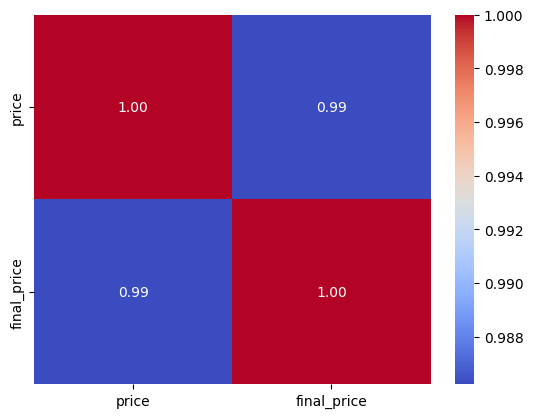

In [ ]:
sns.heatmap(df[['price','final_price']].corr(),annot=True, fmt=".2f", cmap="coolwarm")

In [ ]:
correlation_value = df['price'].corr(df['discount'])
print(f"Correlation between Price and Discount: {correlation_value}")

Correlation between Price and Discount: -0.20287993292872755


In [ ]:
correlation_value = df['seller_rating'].corr(df['rating'])
print(f"Correlation between Seller Rating and Rating: {correlation_value}")

Correlation between Seller Rating and Rating: 0.000543794244049182


In [ ]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,device,payment_method,is_returned,delivery_status
purchase_date,,,,,,,,,,,,,,,,
01-01-2026,Sports,Fitness,Boat,958.24,20.96,757.43,3.0,14,111,4.9,2,Mumbai,Web,UPI,False,In Transit
01-01-2026,Electronics,Mobile,H&M,65372.42,25.58,48649.87,4.9,31,287,2.6,1,Bangalore,Tablet,Cash on Delivery,False,Delayed
01-01-2026,Clothing,Kids,Boat,856.22,64.91,300.41,3.4,20,144,2.7,3,Bangalore,Tablet,Cash on Delivery,False,In Transit
01-01-2026,Home,Furniture,Lenovo,15919.98,9.54,14400.64,4.1,58,241,3.1,4,Mumbai,Web,Cash on Delivery,False,In Transit
01-01-2026,Electronics,Headphones,Lenovo,19568.08,33.98,12918.39,2.9,45,32,4.4,1,Delhi,Tablet,Debit Card,True,Returned


In [ ]:
df["category"].value_counts(normalize=True)

category
Beauty         0.203237
Home           0.200026
Sports         0.199472
Electronics    0.199048
Clothing       0.198217
Name: proportion, dtype: float64

<Axes: xlabel='category'>

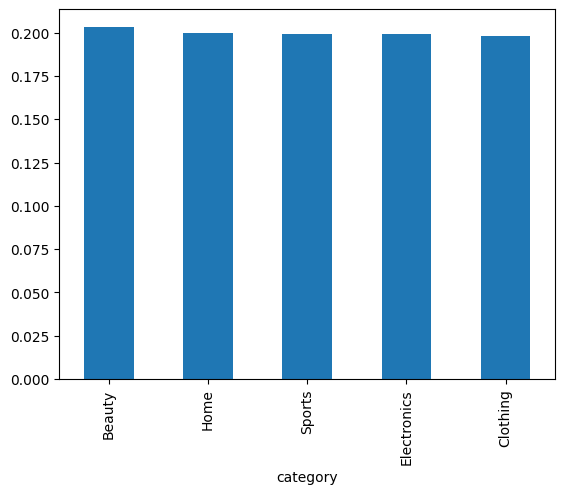

In [ ]:
df["category"].value_counts(normalize=True).plot(kind="bar")

In [ ]:
# I am 21.16 percent sure that the item belongs to the Beauty category.
# I am 20.16 percent sure that the item belongs to the Clothing category.
# I am 19.94 percent sure that the item belongs to the Electronics category.
# I am 19.58 percent sure that the item belongs to the Home category.
# I am 19.16 percent sure that the item belongs to the Sports category.

In [ ]:
df["subcategory"].value_counts(normalize=True)

subcategory
Skincare      0.069542
Decor         0.067401
Makeup        0.067180
Outdoor       0.067069
Cycling       0.066811
Women         0.066608
Kitchen       0.066589
Haircare      0.066515
Men           0.066405
Furniture     0.066035
Fitness       0.065593
Kids          0.065205
Mobile        0.050385
Laptop        0.050163
Headphones    0.049960
Camera        0.048539
Name: proportion, dtype: float64

<Axes: xlabel='subcategory'>

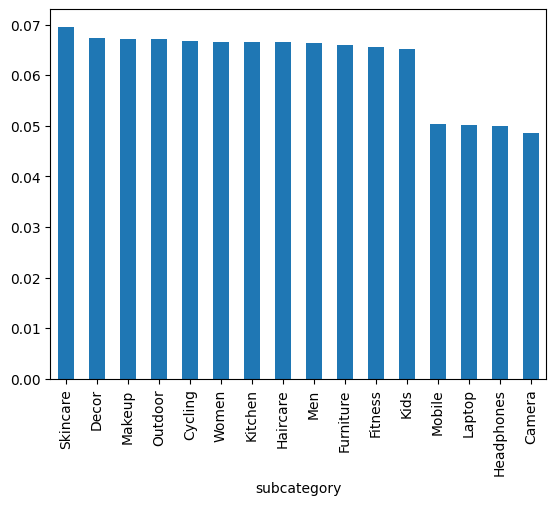

In [ ]:
df["subcategory"].value_counts(normalize=True).plot(kind="bar")

In [ ]:
# I am 7.40 percent sure that the product belongs to Skincare.
# I am 6.98 percent sure that the product belongs to Makeup.
# I am 6.96 percent sure that the product belongs to Women .
# I am 6.80 percent sure that the product belongs to Decor.
# I am 6.80 percent sure that the product belongs to Outdoor.
# I am 6.78 percent sure that the product belongs to Haircare.
# I am 6.74 percent sure that the product belongs to Kitchen.
# I am 6.70 percent sure that the product belongs to Kids.
# I am 6.50 percent sure that the product belongs to Men.
# I am 6.22 percent sure that the product belongs to Cycling.
# I am 6.14 percent sure that the product belongs to Fitness.
# I am 6.04 percent sure that the product belongs to Furniture.
# I am 5.26 percent sure that the product belongs to Laptop.
# I am 5.00 percent sure that the product belongs to Mobile.
# I am 4.92 percent sure that the product belongs to Headphones.
# I am 4.76 percent sure that the product belongs to Camera.

In [ ]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,device,payment_method,is_returned,delivery_status
purchase_date,,,,,,,,,,,,,,,,
01-01-2026,Sports,Fitness,Boat,958.24,20.96,757.43,3.0,14,111,4.9,2,Mumbai,Web,UPI,False,In Transit
01-01-2026,Electronics,Mobile,H&M,65372.42,25.58,48649.87,4.9,31,287,2.6,1,Bangalore,Tablet,Cash on Delivery,False,Delayed
01-01-2026,Clothing,Kids,Boat,856.22,64.91,300.41,3.4,20,144,2.7,3,Bangalore,Tablet,Cash on Delivery,False,In Transit
01-01-2026,Home,Furniture,Lenovo,15919.98,9.54,14400.64,4.1,58,241,3.1,4,Mumbai,Web,Cash on Delivery,False,In Transit
01-01-2026,Electronics,Headphones,Lenovo,19568.08,33.98,12918.39,2.9,45,32,4.4,1,Delhi,Tablet,Debit Card,True,Returned


In [ ]:
sony=df[df["brand"]=="Sony"]
puma=df[df["brand"]=="Puma"]
lg=df[df["brand"]=="LG"]

In [ ]:
sony["category"].value_counts(normalize=True)

category
Beauty         0.212574
Sports         0.203122
Home           0.197406
Clothing       0.193889
Electronics    0.193009
Name: proportion, dtype: float64

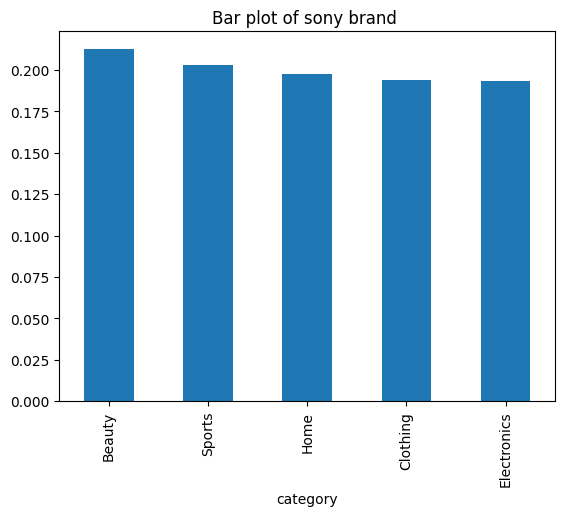

In [ ]:
sony["category"].value_counts(normalize=True).plot(kind="bar")
plt.title("Bar plot of sony brand ")
plt.show()

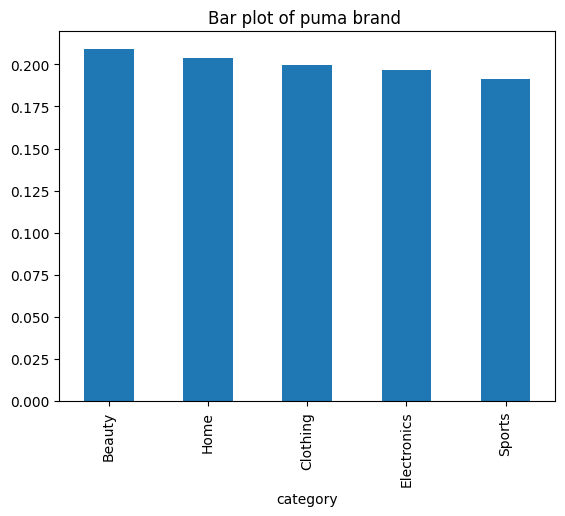

In [ ]:
puma["category"].value_counts(normalize=True).plot(kind="bar")
plt.title("Bar plot of puma brand ")
plt.show()

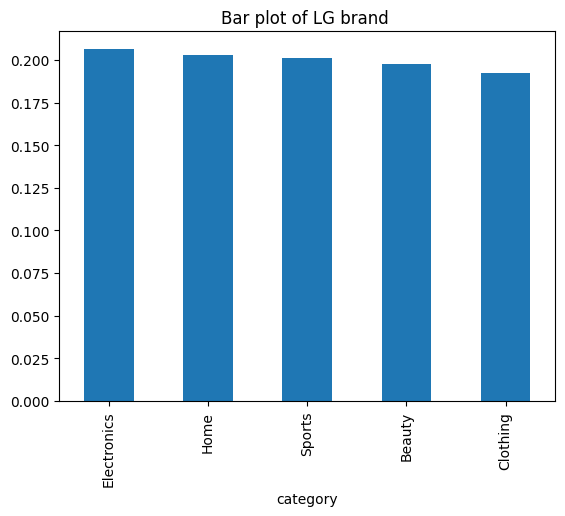

In [ ]:
lg["category"].value_counts(normalize=True).plot(kind="bar")
plt.title("Bar plot of LG brand ")
plt.show()

In [ ]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,device,payment_method,is_returned,delivery_status
purchase_date,,,,,,,,,,,,,,,,
01-01-2026,Sports,Fitness,Boat,958.24,20.96,757.43,3.0,14,111,4.9,2,Mumbai,Web,UPI,False,In Transit
01-01-2026,Electronics,Mobile,H&M,65372.42,25.58,48649.87,4.9,31,287,2.6,1,Bangalore,Tablet,Cash on Delivery,False,Delayed
01-01-2026,Clothing,Kids,Boat,856.22,64.91,300.41,3.4,20,144,2.7,3,Bangalore,Tablet,Cash on Delivery,False,In Transit
01-01-2026,Home,Furniture,Lenovo,15919.98,9.54,14400.64,4.1,58,241,3.1,4,Mumbai,Web,Cash on Delivery,False,In Transit
01-01-2026,Electronics,Headphones,Lenovo,19568.08,33.98,12918.39,2.9,45,32,4.4,1,Delhi,Tablet,Debit Card,True,Returned


In [ ]:
beauty=df[df["category"]=="Beauty"]
clothing=df[df["category"]=="Clothing"]
electronics=df[df["category"]=="Electronics"]

In [ ]:
beauty["brand"].value_counts(normalize=True)

brand
Sony       0.087813
Boat       0.086996
Samsung    0.085634
Nike       0.084998
Adidas     0.084272
Puma       0.084181
Zara       0.083545
HP         0.083182
LG         0.081729
Apple      0.080276
H&M        0.078914
Lenovo     0.078460
Name: proportion, dtype: float64

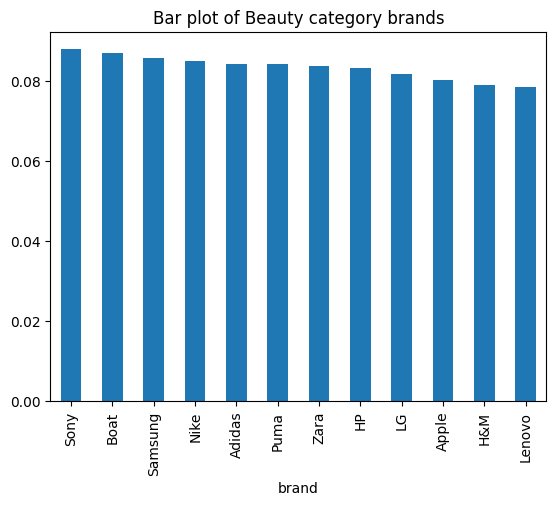

In [ ]:
beauty["brand"].value_counts(normalize=True).plot(kind="bar")
plt.title("Bar plot of Beauty category brands")
plt.show()

In [ ]:
clothing["brand"].value_counts(normalize=True)

brand
H&M        0.085661
Samsung    0.085102
Zara       0.084916
Lenovo     0.084637
Boat       0.083706
HP         0.083706
Apple      0.083520
Puma       0.082309
Sony       0.082123
LG         0.081750
Nike       0.081657
Adidas     0.080912
Name: proportion, dtype: float64

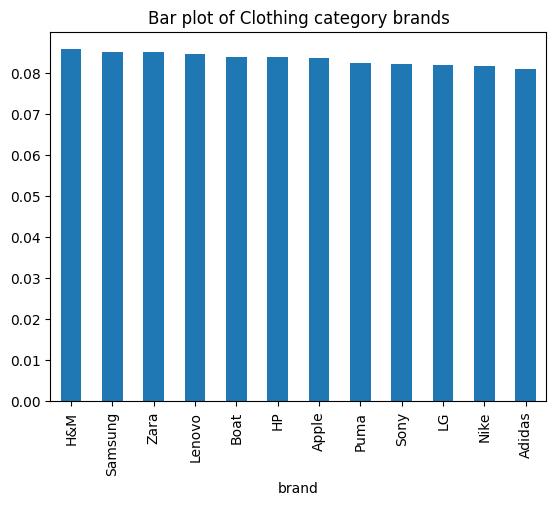

In [ ]:
clothing["brand"].value_counts(normalize=True).plot(kind="bar")
plt.title("Bar plot of Clothing category brands")
plt.show()

In [ ]:
electronics["brand"].value_counts(normalize=True)

brand
LG         0.087251
Nike       0.086045
Lenovo     0.085767
Samsung    0.084376
Boat       0.084098
HP         0.082707
Apple      0.082337
H&M        0.082244
Zara       0.082058
Sony       0.081409
Adidas     0.080946
Puma       0.080760
Name: proportion, dtype: float64

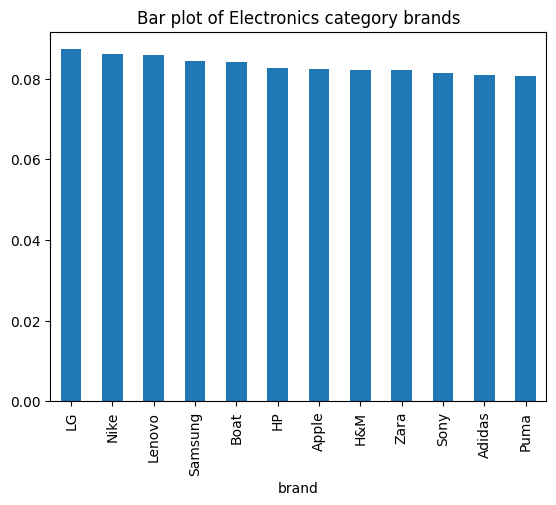

In [ ]:
electronics["brand"].value_counts(normalize=True).plot(kind="bar")
plt.title("Bar plot of Electronics category brands")
plt.show()

In [ ]:
df["shipping_time_days"].value_counts(normalize=True)

shipping_time_days
1    0.233985
3    0.168577
5    0.167230
2    0.165107
4    0.164812
6    0.100290
Name: proportion, dtype: float64

<Axes: xlabel='shipping_time_days'>

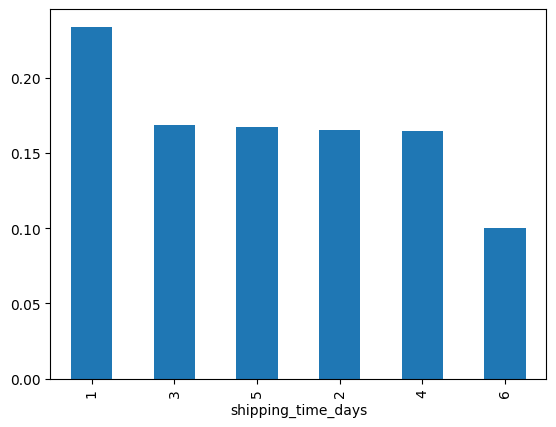

In [ ]:
df["shipping_time_days"].value_counts(normalize=True).plot(kind="bar")

In [ ]:
# i am 21.94 percent sure that items will be delivered within 1 day.
# i am 17.86 percent sure that product will delivered in 5 days
# i am  17.56 percent sure that product will be delivered in 4 days.
# i am  16.42 percent sure that product will be delivered in 3 days.
# i am  16.04 percent sure that product will be delivered in 2 days.
# i am  10.18 percent sure that product will be delivered in 6 days.

In [ ]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,device,payment_method,is_returned,delivery_status
purchase_date,,,,,,,,,,,,,,,,
01-01-2026,Sports,Fitness,Boat,958.24,20.96,757.43,3.0,14,111,4.9,2,Mumbai,Web,UPI,False,In Transit
01-01-2026,Electronics,Mobile,H&M,65372.42,25.58,48649.87,4.9,31,287,2.6,1,Bangalore,Tablet,Cash on Delivery,False,Delayed
01-01-2026,Clothing,Kids,Boat,856.22,64.91,300.41,3.4,20,144,2.7,3,Bangalore,Tablet,Cash on Delivery,False,In Transit
01-01-2026,Home,Furniture,Lenovo,15919.98,9.54,14400.64,4.1,58,241,3.1,4,Mumbai,Web,Cash on Delivery,False,In Transit
01-01-2026,Electronics,Headphones,Lenovo,19568.08,33.98,12918.39,2.9,45,32,4.4,1,Delhi,Tablet,Debit Card,True,Returned


In [ ]:
df["final_price"].skew()

np.float64(2.2446209451316483)

In [ ]:
from scipy.stats import boxcox

In [ ]:
# Keep the original column intact and store the transformed values separately,
# so later steps can choose which scale (original vs. transformed) to work on.
final_price_boxcox, lda = boxcox(df["final_price"])
df["final_price_boxcox"] = final_price_boxcox

In [ ]:
print(df["final_price_boxcox"].min())
print(df["final_price_boxcox"].max())
print(df["final_price_boxcox"].mean())

4.177402992836296
8.647488480308919
6.840116758039157


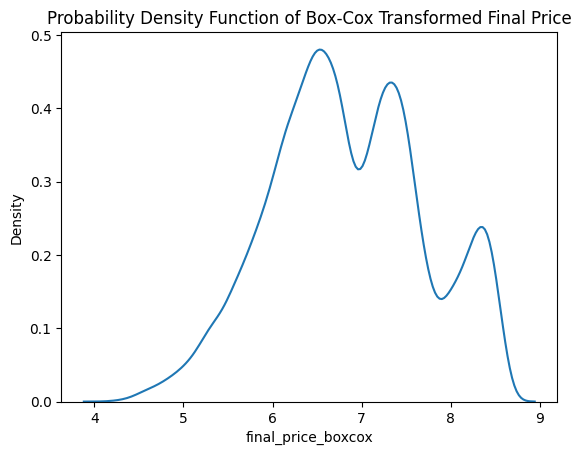

In [ ]:
sns.kdeplot(df["final_price_boxcox"])
plt.title("Probability Density Function of Box-Cox Transformed Final Price")

plt.show()

In [ ]:
# Use the ORIGINAL (untransformed) final_price for anything that needs to be
# interpreted in real currency units, such as category breakdowns and
# probability ranges expressed in actual price terms.
threshold = df['final_price'].quantile(0.75)
high_price = df[df['final_price'] > threshold]

In [ ]:
cond_prob = high_price['category'].value_counts(normalize=True)

In [ ]:
print("Conditional Probabilities given High Price:")
print(cond_prob)

Conditional Probabilities given High Price:
category
Electronics    0.707294
Home           0.218367
Sports         0.074339
Name: proportion, dtype: float64


<Axes: xlabel='category'>

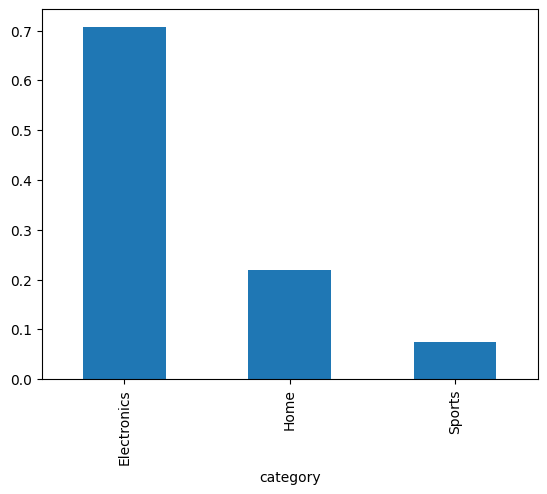

In [ ]:
cond_prob.plot(kind="bar")

In [ ]:
df["final_price"]

purchase_date
01-01-2026      757.43
01-01-2026    48649.87
01-01-2026      300.41
01-01-2026    14400.64
01-01-2026    12918.39
                ...   
31-12-2025     6896.71
31-12-2025     2358.27
31-12-2025     1569.96
31-12-2025     7818.99
31-12-2025      461.52
Name: final_price, Length: 54183, dtype: float64

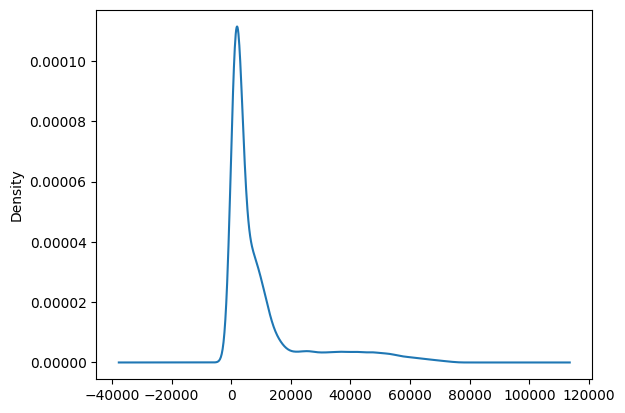

In [ ]:
df["final_price"].plot(kind="density")
plt.axvspan(3,7,alpha=0.4)

In [ ]:
from scipy.stats import gaussian_kde

In [ ]:
# NOTE: this KDE is fit on the ORIGINAL final_price scale (real currency units),
# not the Box-Cox transformed values, so the probability below is interpretable
# as "price falling between 3 and 7" in actual price terms.
kde = gaussian_kde(df["final_price"])

In [ ]:
kde.integrate_box_1d(3,7)

np.float64(0.0002798024662835571)

In [31]:
import pandas as pd
from sqlalchemy import create_engine

CSV_PATH = r"C:\Users\nares\OneDrive\Desktop\Sales_analysis\amazon_Sales_Dataset.csv"
MYSQL_USER = "root"
MYSQL_PASSWORD = "9346"
MYSQL_HOST = "localhost"
MYSQL_PORT = 3306
MYSQL_DATABASE = "Amazon_db"
TABLE_NAME = "sales"

df = pd.read_csv(CSV_PATH)
df['purchase_date'] = pd.to_datetime(df['purchase_date'], format='%d-%m-%Y')

engine = create_engine(f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}")
df.to_sql(TABLE_NAME, con=engine, if_exists="replace", index=False, chunksize=5000)

print(f"Loaded {len(df)} rows into {TABLE_NAME}")

TypeError: __init__() got multiple values for argument 'schema'